In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import Counter


In [2]:
# Load the dataset
file_path = "phishing_dataset_nu.csv"  # Change this to your local file path
df = pd.read_csv(file_path)


In [3]:
df = df.drop(df.columns[-1], axis='columns') # Drop an unnamed column

In [4]:
df.head()

,Clicked At,Replied At,Data Entered At,Attachment Opened At,Macro Enabled At,QR Code Scanned At,Opened At,Reported,Scheduled,Delivered At,Job Title,Division,Browser,Browser Version,Operating System,Email Template,Current PPP,Risk Score,Department
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11/26/24 19:54,11/26/24 19:54,Administration,EMP IT SYSTEMS AND ARCH,NaN,NaN,NaN,T-Mobile: Win the new Iphone Xs with T-Mobile ...,0.015748,46.0773,IT SYSTEMS AND ARCH
1,NaN,NaN,NaN,NaN,NaN,NaN,11/27/24 6:05,NaN,11/26/24 21:07,11/26/24 21:07,Administration,EMP IT USER SERVICES,NaN,NaN,NaN,Crypto University Giveaway (Link),0.000000,46.0773,IT USER SERVICES
2,NaN,NaN,NaN,NaN,NaN,NaN,11/27/24 18:26,11/27/24 18:26,11/27/24 16:00,11/27/24 16:00,Administration,EMP VP - STUDENT AFFAIRS,NaN,NaN,NaN,Your Facebook Ads Receipt (Link) (PDF Attachment),0.038168,39.1328,VP - STUDENT AFFAIRS
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11/27/24 21:07,11/27/24 21:07,Administration,EMP COMDNT CADETS,NaN,NaN,NaN,EA Playstation Account Notification (Link) (QR...,0.090909,46.0773,COMDNT CADETS
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11/27/24 15:01,11/27/24 15:01,Administration,EMP NURSING,NaN,NaN,NaN,T-Mobile: Win the new Iphone Xs with T-Mobile ...,0.060606,46.0773,ENGLISH


In [5]:
# =============================
# DATA CLEANING & PREPROCESSING
# =============================

# Drop completely empty columns if any
df.dropna(axis=1, how="all", inplace=True)

# Trim whitespace from column names
df.columns = df.columns.str.strip()

# Drop unnecessary timestamp columns (mostly empty)
cols_to_drop = [
    "Clicked At", "Replied At", "Data Entered At", "Attachment Opened At",
    "Macro Enabled At", "QR Code Scanned At", "Opened At", "Reported",
    "Scheduled", "Delivered At"
]
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True, errors="ignore")

# Convert "Risk Score" to numeric
df["Risk Score"] = pd.to_numeric(df["Risk Score"], errors="coerce")

# Fill missing categorical values with "Unknown"
categorical_cols = ["Job Title", "Division", "Email Template", "Department"]
for col in categorical_cols:
    if col in df.columns:
        df.fillna({col: "Unknown"})


In [6]:
df.head()

,Job Title,Division,Browser,Browser Version,Operating System,Email Template,Current PPP,Risk Score,Department
0,Administration,EMP IT SYSTEMS AND ARCH,NaN,NaN,NaN,T-Mobile: Win the new Iphone Xs with T-Mobile ...,0.015748,46.0773,IT SYSTEMS AND ARCH
1,Administration,EMP IT USER SERVICES,NaN,NaN,NaN,Crypto University Giveaway (Link),0.000000,46.0773,IT USER SERVICES
2,Administration,EMP VP - STUDENT AFFAIRS,NaN,NaN,NaN,Your Facebook Ads Receipt (Link) (PDF Attachment),0.038168,39.1328,VP - STUDENT AFFAIRS
3,Administration,EMP COMDNT CADETS,NaN,NaN,NaN,EA Playstation Account Notification (Link) (QR...,0.090909,46.0773,COMDNT CADETS
4,Administration,EMP NURSING,NaN,NaN,NaN,T-Mobile: Win the new Iphone Xs with T-Mobile ...,0.060606,46.0773,ENGLISH


In [7]:
print(df.shape)

(16122, 9)


In [8]:
value=pd.DataFrame([df['Operating System'].value_counts(),df['Browser Version'].value_counts(),df['Browser'].value_counts()])
value = value.transpose()
print(value)

                 count  count  count
ios              239.0    NaN    NaN
windows           93.0    NaN    NaN
mac               71.0    NaN    NaN
android           37.0    NaN    NaN
chrome_os          2.0    NaN    NaN
17.0               NaN  152.0    NaN
16.0               NaN   52.0    NaN
121.0              NaN   45.0    NaN
123.0              NaN   43.0    NaN
122.0              NaN   43.0    NaN
124.0              NaN   27.0    NaN
131.0              NaN   27.0    NaN
18.0               NaN   12.0    NaN
132.0              NaN    4.0    NaN
107.0              NaN    3.0    NaN
120.0              NaN    3.0    NaN
133.0              NaN    3.0    NaN
130.0              NaN    3.0    NaN
22.0               NaN    2.0    NaN
115.0              NaN    2.0    NaN
113.0              NaN    2.0    NaN
125.0              NaN    2.0    NaN
86.0               NaN    2.0    NaN
119.0              NaN    2.0    NaN
109.0              NaN    1.0    NaN
110.0              NaN    1.0    NaN
4

In [9]:
df['Job Title'].value_counts()

Job Title
Student                      11010
Administration                5104
Admissions Student Worker        4
Music                            4
Name: count, dtype: int64

In [10]:
df = df.drop(['Operating System','Browser Version','Browser'], axis='columns') # Drop mostly null columns


In [11]:
# =============================
# FEATURE ENGINEERING
# =============================

# Define target variable: Clicked (1 if above median risk score, 0 otherwise)
df["Clicked"] = df["Risk Score"].apply(lambda x: 1 if x > df["Risk Score"].median() else 0)
df.drop(columns=["Risk Score"], inplace=True)

# Encode categorical features
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoder for future decoding if needed

# Define features and target
X = df.drop(columns=["Clicked"])
y = df["Clicked"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [12]:
df.head()

,Job Title,Division,Email Template,Current PPP,Department,Clicked
0,0,65,53,0.015748,73,0
1,0,66,15,0.000000,74,0
2,0,118,64,0.038168,152,0
3,0,28,18,0.090909,32,0
4,0,91,53,0.060606,53,0


### After preprocessing and cleaning the data, there are 5 features left (**Job Title**, **Division**, **Email Template**, **Current PPP**, **Department**)

In [14]:
# =============================
# SUPERVISED LEARNING (CLASSIFICATION)
# =============================

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42, n_estimators=100)
}

results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[model_name] = {
        "Classification Report": classification_report(y_test, y_pred, output_dict=True),
        "ROC AUC Score": roc_auc_score(y_test, y_proba)
    }

# Convert classification results to DataFrame
classification_results = pd.DataFrame({
    model: results[model]["Classification Report"]["1"] for model in results
}).T

classification_results["ROC AUC Score"] = [results[model]["ROC AUC Score"] for model in results]

# Display classification results
print("\n=== Classification Model Results ===")
print(classification_results)


=== Classification Model Results ===
                     precision    recall  f1-score  support  ROC AUC Score
Logistic Regression   0.080471  0.976190  0.148685     84.0       0.923017
Random Forest         0.581633  0.678571  0.626374     84.0       0.962326


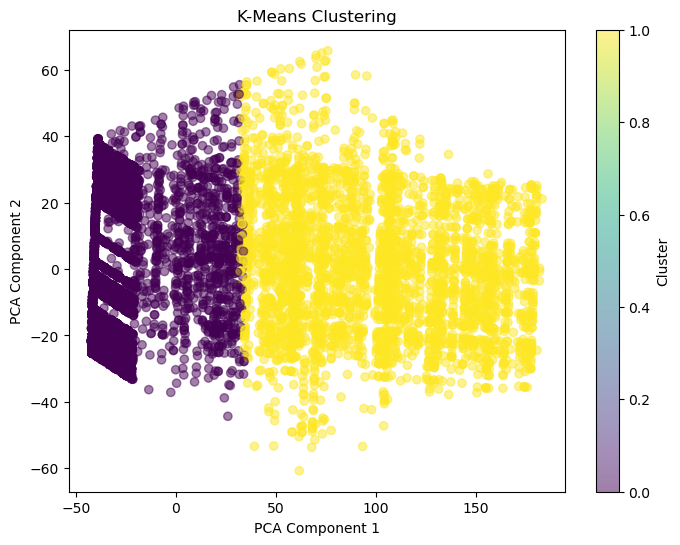

In [15]:
# =============================
# UNSUPERVISED LEARNING (CLUSTERING & ANOMALY DETECTION)
# =============================

# K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

# # Isolation Forest for Anomaly Detection
# iso_forest = IsolationForest(contamination=0.02, random_state=42)
# df["Anomaly"] = iso_forest.fit_predict(X)

# # Convert Anomaly label (-1 for anomalies, 1 for normal) into binary (1 = anomaly, 0 = normal)
# df["Anomaly"] = df["Anomaly"].apply(lambda x: 1 if x == -1 else 0)

# =============================
# VISUALIZATION
# =============================

# PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot K-Means Clustering
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], cmap="viridis", alpha=0.5)
plt.title("K-Means Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

# # Plot Anomalies detected by Isolation Forest
# plt.figure(figsize=(8,6))
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Anomaly"], cmap="coolwarm", alpha=0.5)
# plt.title("Anomaly Detection with Isolation Forest")
# plt.xlabel("PCA Component 1")
# plt.ylabel("PCA Component 2")
# plt.colorbar(label="Anomaly (1=Anomalous)")
# plt.show()


In [16]:
# =============================
# RESULTS SUMMARY
# =============================

print("\n=== Clustering Results ===")
print("K-Means Cluster Distribution:", Counter(df["Cluster"]))
# print("Isolation Forest Anomaly Distribution:", Counter(df["Anomaly"]))


=== Clustering Results ===
K-Means Cluster Distribution: Counter({0: 12354, 1: 3768})


/var/folders/rn/4nj37fp17b186g3qlc229y440000gn/T/ipykernel_51271/3508990851.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="coolwarm")


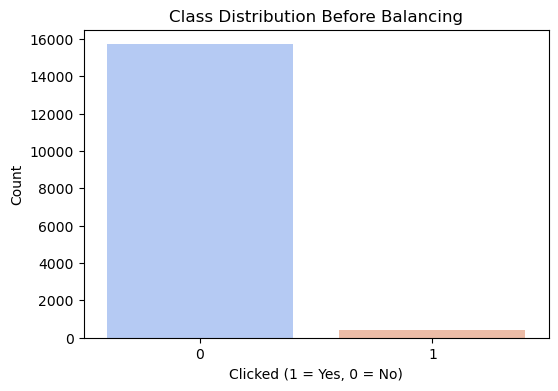

Class distribution before balancing: Counter({0: 15701, 1: 421})
Class distribution after balancing: Counter({0: 15701, 1: 15701})


/var/folders/rn/4nj37fp17b186g3qlc229y440000gn/T/ipykernel_51271/3508990851.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_balanced, palette="coolwarm")


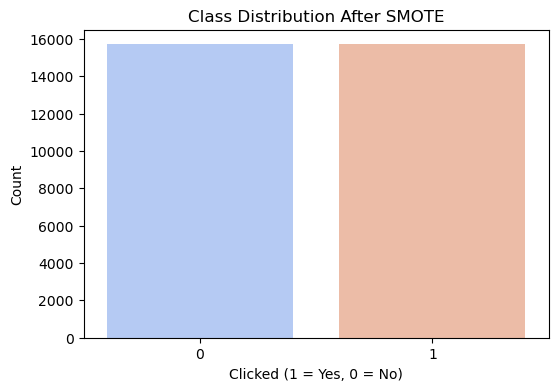


=== Classification Model Results ===
                     precision    recall  f1-score  support  ROC AUC Score
Logistic Regression   0.767591  0.951911  0.849872   3140.0       0.915543
Random Forest         0.977904  0.986624  0.982245   3140.0       0.998555


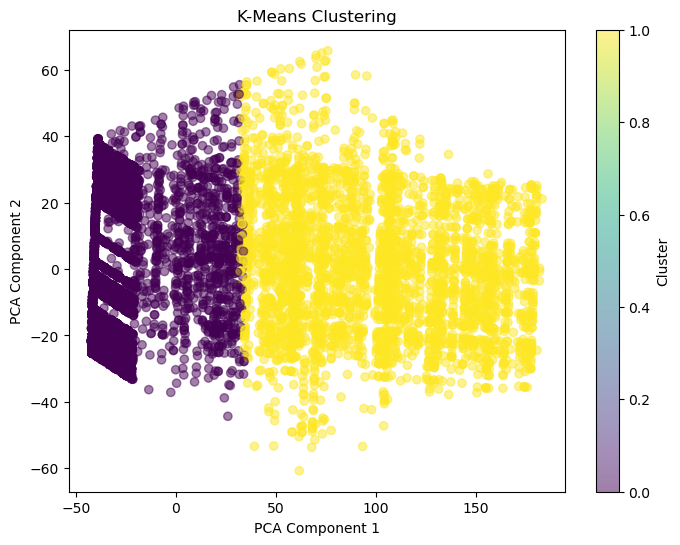


=== Clustering Results ===
K-Means Cluster Distribution: Counter({0: 12354, 1: 3768})


In [17]:
from imblearn.over_sampling import SMOTE

# Define features and target
X = df.drop(columns=["Clicked"])
y = df["Clicked"]

# =============================
# VISUALIZE CLASS IMBALANCE
# =============================

plt.figure(figsize=(6,4))
sns.countplot(x=y, palette="coolwarm")
plt.title("Class Distribution Before Balancing")
plt.xlabel("Clicked (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

print("Class distribution before balancing:", Counter(y))

# =============================
# BALANCE THE DATA USING SMOTE
# =============================

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

# Check new distribution
print("Class distribution after balancing:", Counter(y_balanced))

plt.figure(figsize=(6,4))
sns.countplot(x=y_balanced, palette="coolwarm")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Clicked (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =============================
# SUPERVISED LEARNING (CLASSIFICATION)
# =============================

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
}

results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[model_name] = {
        "Classification Report": classification_report(y_test, y_pred, output_dict=True),
        "ROC AUC Score": roc_auc_score(y_test, y_proba)
    }

# Convert classification results to DataFrame
classification_results = pd.DataFrame({
    model: results[model]["Classification Report"]["1"] for model in results
}).T

classification_results["ROC AUC Score"] = [results[model]["ROC AUC Score"] for model in results]

# Display classification results
print("\n=== Classification Model Results ===")
print(classification_results)

# =============================
# UNSUPERVISED LEARNING (CLUSTERING & ANOMALY DETECTION)
# =============================

# K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

# # Isolation Forest for Anomaly Detection
# iso_forest = IsolationForest(contamination=0.02, random_state=42)
# df["Anomaly"] = iso_forest.fit_predict(X)

# # Convert Anomaly label (-1 for anomalies, 1 for normal) into binary (1 = anomaly, 0 = normal)
# df["Anomaly"] = df["Anomaly"].apply(lambda x: 1 if x == -1 else 0)

# =============================
# VISUALIZATION
# =============================

# # PCA for dimensionality reduction
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X)

# Plot K-Means Clustering
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], cmap="viridis", alpha=0.5)
plt.title("K-Means Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

# # Plot Anomalies detected by Isolation Forest
# plt.figure(figsize=(8,6))
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Anomaly"], cmap="coolwarm", alpha=0.5)
# plt.title("Anomaly Detection with Isolation Forest")
# plt.xlabel("PCA Component 1")
# plt.ylabel("PCA Component 2")
# plt.colorbar(label="Anomaly (1=Anomalous)")
# plt.show()

# =============================
# RESULTS SUMMARY
# =============================

print("\n=== Clustering Results ===")
print("K-Means Cluster Distribution:", Counter(df["Cluster"]))
# print("Isolation Forest Anomaly Distribution:", Counter(df["Anomaly"]))



/var/folders/rn/4nj37fp17b186g3qlc229y440000gn/T/ipykernel_51271/388536258.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="coolwarm")


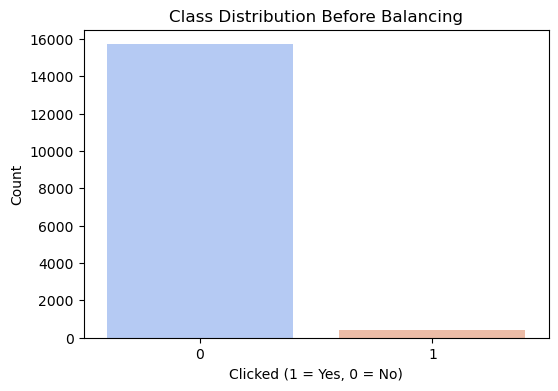

Class distribution before balancing: Counter({0: 15701, 1: 421})
Class distribution after balancing: Counter({0: 526, 1: 421})


/var/folders/rn/4nj37fp17b186g3qlc229y440000gn/T/ipykernel_51271/388536258.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_balanced, palette="coolwarm")


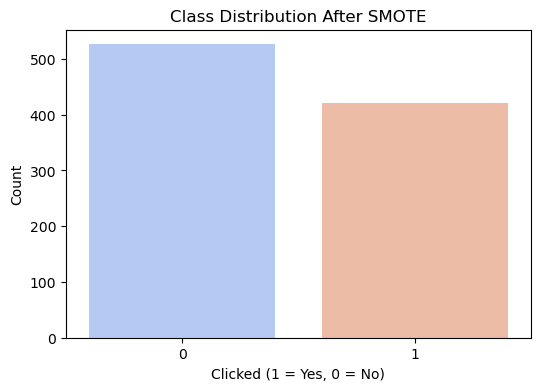


=== Classification Model Results ===
                     precision    recall  f1-score  support  ROC AUC Score
Logistic Regression   0.709091  0.928571  0.804124     84.0       0.888252
Random Forest         0.843750  0.964286  0.900000     84.0       0.968497


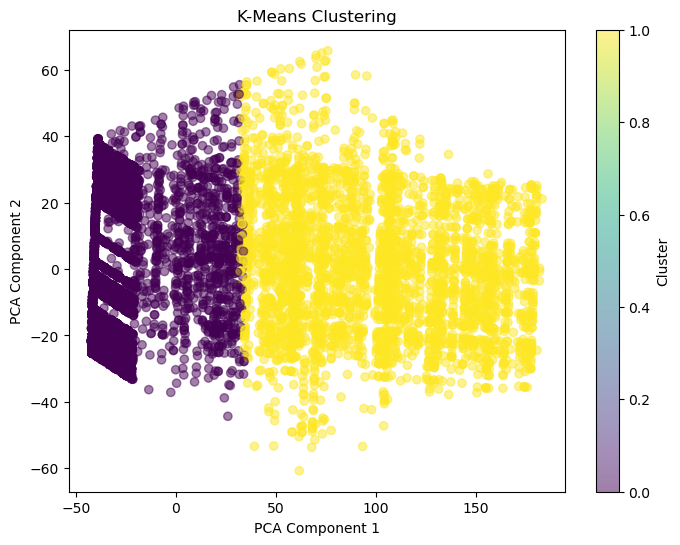


=== Clustering Results ===
K-Means Cluster Distribution: Counter({0: 12354, 1: 3768})


In [18]:
from imblearn.under_sampling import RandomUnderSampler


# Define features and target
X = df.drop(columns=["Clicked"])
y = df["Clicked"]

# =============================
# VISUALIZE CLASS IMBALANCE
# =============================

plt.figure(figsize=(6,4))
sns.countplot(x=y, palette="coolwarm")
plt.title("Class Distribution Before Balancing")
plt.xlabel("Clicked (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

print("Class distribution before balancing:", Counter(y))

# =============================
# BALANCE THE DATA USING SMOTE
# =============================

under = RandomUnderSampler(sampling_strategy=0.8)
X_balanced, y_balanced = under.fit_resample(X, y)

# Check new distribution
print("Class distribution after balancing:", Counter(y_balanced))

plt.figure(figsize=(6,4))
sns.countplot(x=y_balanced, palette="coolwarm")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Clicked (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =============================
# SUPERVISED LEARNING (CLASSIFICATION)
# =============================

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
}

results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[model_name] = {
        "Classification Report": classification_report(y_test, y_pred, output_dict=True),
        "ROC AUC Score": roc_auc_score(y_test, y_proba)
    }

# Convert classification results to DataFrame
classification_results = pd.DataFrame({
    model: results[model]["Classification Report"]["1"] for model in results
}).T

classification_results["ROC AUC Score"] = [results[model]["ROC AUC Score"] for model in results]

# Display classification results
print("\n=== Classification Model Results ===")
print(classification_results)

# =============================
# UNSUPERVISED LEARNING (CLUSTERING & ANOMALY DETECTION)
# =============================

# K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

# # Isolation Forest for Anomaly Detection
# iso_forest = IsolationForest(contamination=0.02, random_state=42)
# df["Anomaly"] = iso_forest.fit_predict(X)

# # Convert Anomaly label (-1 for anomalies, 1 for normal) into binary (1 = anomaly, 0 = normal)
# df["Anomaly"] = df["Anomaly"].apply(lambda x: 1 if x == -1 else 0)

# =============================
# VISUALIZATION
# =============================

# # PCA for dimensionality reduction
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X)

# Plot K-Means Clustering
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], cmap="viridis", alpha=0.5)
plt.title("K-Means Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

# # Plot Anomalies detected by Isolation Forest
# plt.figure(figsize=(8,6))
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Anomaly"], cmap="coolwarm", alpha=0.5)
# plt.title("Anomaly Detection with Isolation Forest")
# plt.xlabel("PCA Component 1")
# plt.ylabel("PCA Component 2")
# plt.colorbar(label="Anomaly (1=Anomalous)")
# plt.show()

# =============================
# RESULTS SUMMARY
# =============================

print("\n=== Clustering Results ===")
print("K-Means Cluster Distribution:", Counter(df["Cluster"]))
# print("Isolation Forest Anomaly Distribution:", Counter(df["Anomaly"]))



,Cluster,Email Template,Count
0,0,25,460
1,0,51,445
2,0,9,442
3,0,61,441
4,0,13,438
5,1,40,221
6,1,16,160
7,1,28,151
8,1,23,147
9,1,18,144


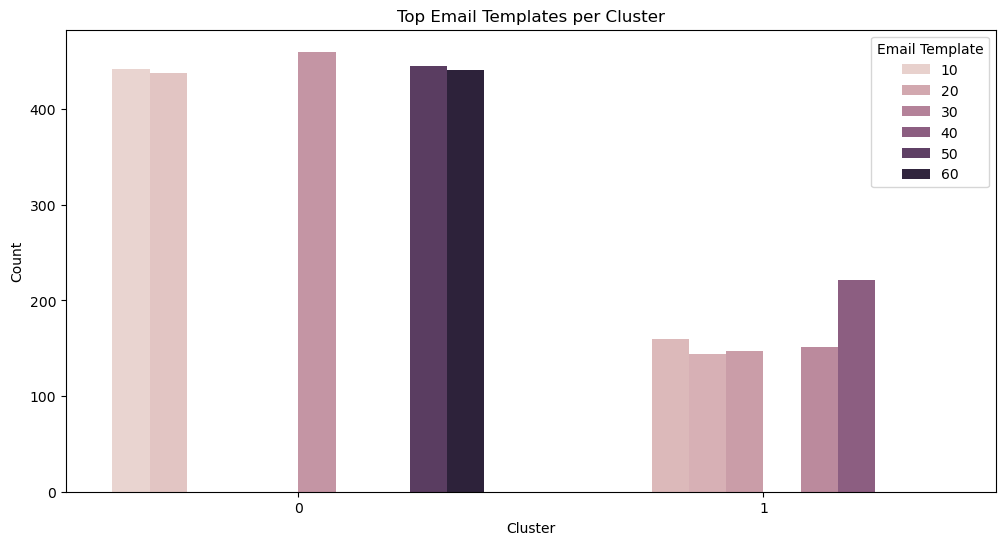

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Cluster column exists
if "Cluster" in df.columns and "Job Title" in df.columns and "Email Template" in df.columns:
    # Label clusters by most common job titles
    job_title_counts = df.groupby("Cluster")["Job Title"].value_counts().groupby(level=0).head(1)
    cluster_labels = {index: title for index, title in job_title_counts.index}

    # Rename clusters based on job titles
    df["Cluster_Label"] = df["Cluster"].map(cluster_labels)

    # Analyze top email templates per cluster
    top_email_templates = df.groupby("Cluster")["Email Template"].value_counts().groupby(level=0).head(5)

    # Convert to DataFrame for visualization
    top_email_templates_df = top_email_templates.reset_index(name="Count")

    # Display DataFrame
    from IPython.display import display
    display(top_email_templates_df)

    # Visualize the email templates per cluster
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_email_templates_df, x="Cluster", y="Count", hue="Email Template")
    plt.title("Top Email Templates per Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Count")
    plt.legend(title="Email Template", bbox_to_anchor=(1, 1))
    plt.show()
else:
    print("Required columns are missing in the dataframe.")



===== Job Title Legend =====
0: Administration
3: Student
1: Admissions Student Worker
2: Music

===== Email Template Legend =====
53: T-Mobile: Win the new Iphone Xs with T-Mobile (Link)
15: Crypto University Giveaway (Link)
64: Your Facebook Ads Receipt (Link) (PDF Attachment)
18: EA Playstation Account Notification (Link) (QR Code)
46: Slack: Mandatory mobile app update (QR Code)
32: LinkedIn: Install LinkedIn Secure app (Link)
35: LinkedIn: Who's searching for you online? (Link)
59: UPS: Service Temporarily Unavailable (QR Code)
68: jetBlue: Chance to win a FREE upgrade on your flight to New York! (Link)
39: Netflix Alerts: The Wait is Over! (Link)
44: ParkingEye: Parking Ticket Refund (Link)
16: Dick's: Congratulations! (QR Code)
23: Get Spotify Premium for Free! (QR Code)
34: LinkedIn: Verification Required! (Link) (Credentials Landing Page)
12: Chase: You have a payment on hold (Link)
41: New invitation to publish your book (Link)
31: Kmart: Kmart Deals are Starting Soon! (Link

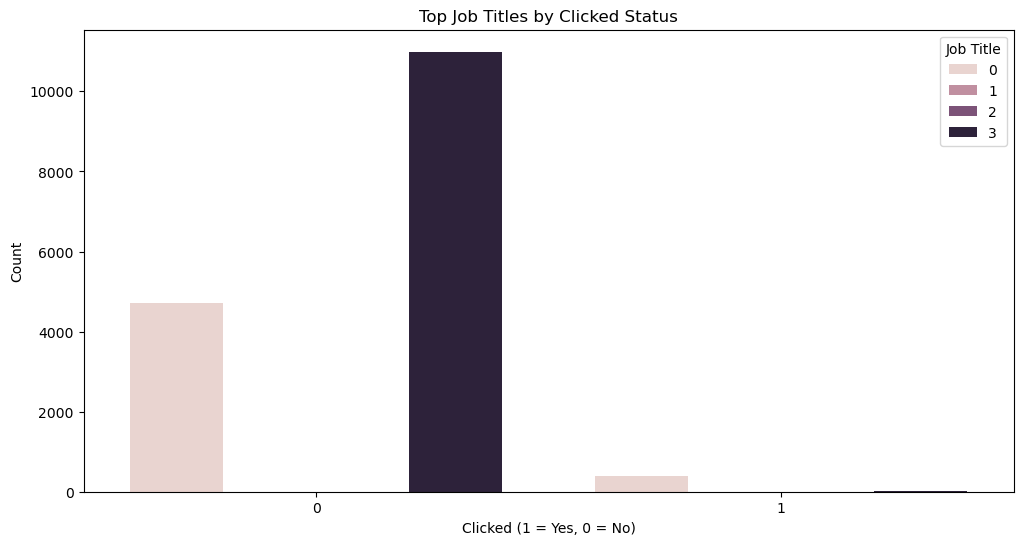

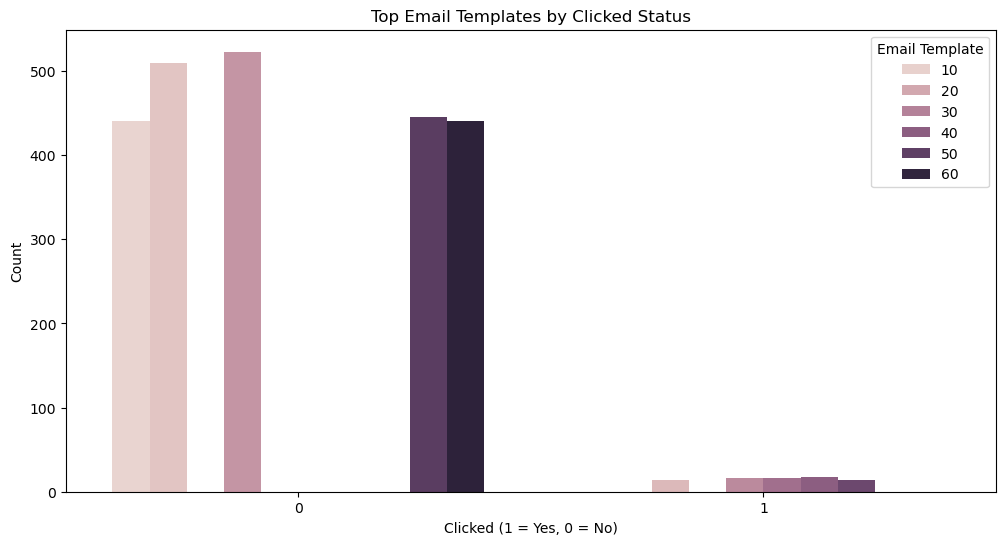

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
# Check if necessary columns exist
if {"Clicked", "Job Title", "Email Template"}.issubset(df.columns):
    
    # Decode Job Title and Email Template using stored label encoders
    df["Job Title decoded"] = df["Job Title"].map(lambda x: label_encoders["Job Title"].inverse_transform([x])[0])
    df["Email Template decoded"] = df["Email Template"].map(lambda x: label_encoders["Email Template"].inverse_transform([x])[0])

    # Create decoding dictionaries
    job_title_decoder = {x: label_encoders["Job Title"].inverse_transform([x])[0] for x in df["Job Title"].unique()}
    email_template_decoder = {x: label_encoders["Email Template"].inverse_transform([x])[0] for x in df["Email Template"].unique()}

    # Analyze job titles based on 'Clicked' status
    job_title_clicked = df.groupby("Clicked")["Job Title"].value_counts().groupby(level=0).head(5)
    job_title_clicked_df = job_title_clicked.reset_index(name="Count")

    # Analyze email templates based on 'Clicked' status
    email_template_clicked = df.groupby("Clicked")["Email Template"].value_counts().groupby(level=0).head(5)
    email_template_clicked_df = email_template_clicked.reset_index(name="Count")

    # Print legend for Job Titles
    print("\n===== Job Title Legend =====")
    for encoded, decoded in job_title_decoder.items():
        print(f"{encoded}: {decoded}")

    # Print legend for Email Templates
    print("\n===== Email Template Legend =====")
    for encoded, decoded in email_template_decoder.items():
        print(f"{encoded}: {decoded}")

    # Display the top job titles per 'Clicked' status
    print("\nTop Job Titles per Clicked Status:")
    print(job_title_clicked_df)

    # Display the top email templates per 'Clicked' status
    print("\nTop Email Templates per Clicked Status:")
    print(email_template_clicked_df)

    # Visualize the job titles per 'Clicked' status
    plt.figure(figsize=(12, 6))
    sns.barplot(data=job_title_clicked_df, x="Clicked", y="Count", hue="Job Title")
    plt.title("Top Job Titles by Clicked Status")
    plt.xlabel("Clicked (1 = Yes, 0 = No)")
    plt.ylabel("Count")
    plt.legend(title="Job Title", bbox_to_anchor=(1, 1))
    plt.show()

    # Visualize the email templates per 'Clicked' status
    plt.figure(figsize=(12, 6))
    sns.barplot(data=email_template_clicked_df, x="Clicked", y="Count", hue="Email Template")
    plt.title("Top Email Templates by Clicked Status")
    plt.xlabel("Clicked (1 = Yes, 0 = No)")
    plt.ylabel("Count")
    plt.legend(title="Email Template", bbox_to_anchor=(1, 1))
    plt.show()

else:
    print("Required columns are missing in the dataframe.")

In [23]:
label_encoders["Job Title"].inverse_transform(df['Job Title'])

array(['Administration', 'Administration', 'Administration', ...,
       'Student', 'Student', 'Student'], dtype=object)


Top Job Titles per Clicked Status:
   Clicked          Job Title decoded  Count
0        0                    Student  10990
1        0             Administration   4703
2        0  Admissions Student Worker      4
3        0                      Music      4
4        1             Administration    401
5        1                    Student     20

Top Email Templates per Clicked Status:
   Clicked                             Email Template decoded  Count
0        0                   Hello All Cat Lovers!!!!! (Link)    523
1        0   Chipotle: Go BOGO with our mobile app! (QR Code)    510
2        0                        Steam: Malware Alert (Link)    445
3        0  Apples: You recently requested a password rese...    441
4        0                     Withdrawal is available (Link)    441
5        1  Netflix: Your Netflix account is on hold! (Lin...     17
6        1  Instagram: Unidentified Device (Link) (Credent...     16
7        1   LinkedIn: Who's searching for you online? (

/var/folders/rn/4nj37fp17b186g3qlc229y440000gn/T/ipykernel_51271/3741957522.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_job_titles = job_title_clicked.groupby("Clicked").apply(lambda x: x.nlargest(5, "Count")).reset_index(drop=True)
/var/folders/rn/4nj37fp17b186g3qlc229y440000gn/T/ipykernel_51271/3741957522.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_email_templates = email_templat

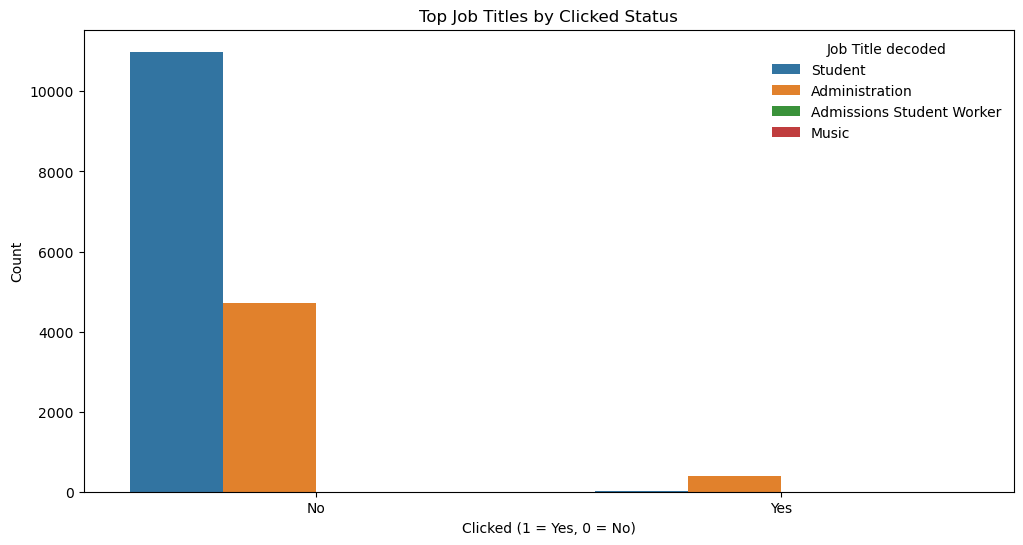

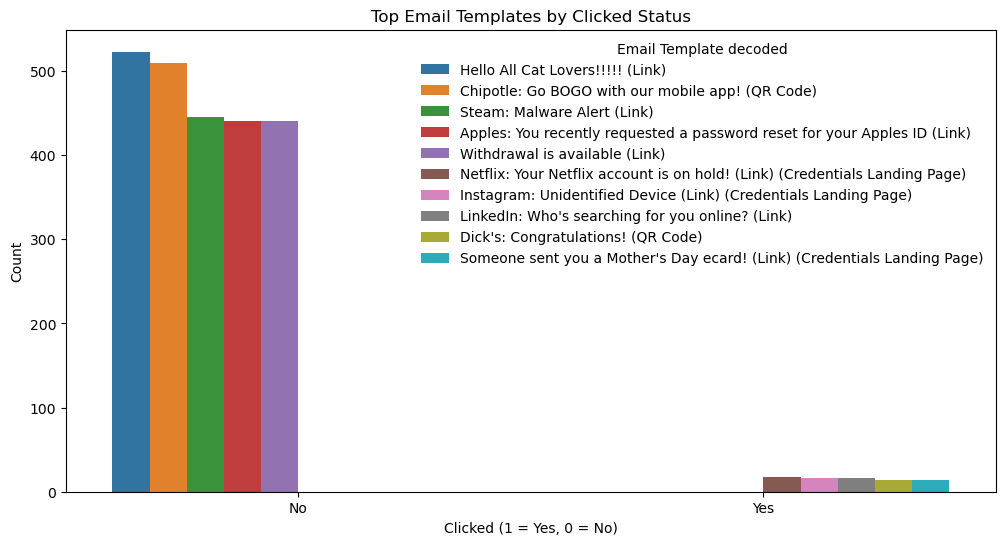

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Check if necessary columns exist
if {"Clicked", "Job Title", "Email Template"}.issubset(df.columns):
    
    # Decode Job Title and Email Template using stored label encoders
    df["Job Title decoded"] = df["Job Title"].map(lambda x: label_encoders["Job Title"].inverse_transform([x])[0])
    df["Email Template decoded"] = df["Email Template"].map(lambda x: label_encoders["Email Template"].inverse_transform([x])[0])

    # Analyze job titles based on 'Clicked' status
    job_title_clicked = df.groupby(["Clicked", "Job Title decoded"]).size().reset_index(name="Count")
    top_job_titles = job_title_clicked.groupby("Clicked").apply(lambda x: x.nlargest(5, "Count")).reset_index(drop=True)

    # Analyze email templates based on 'Clicked' status
    email_template_clicked = df.groupby(["Clicked", "Email Template decoded"]).size().reset_index(name="Count")
    top_email_templates = email_template_clicked.groupby("Clicked").apply(lambda x: x.nlargest(5, "Count")).reset_index(drop=True)

    # Display the top job titles per 'Clicked' status
    print("\nTop Job Titles per Clicked Status:")
    print(top_job_titles)

    # Display the top email templates per 'Clicked' status
    print("\nTop Email Templates per Clicked Status:")
    print(top_email_templates)

    # Visualize the job titles per 'Clicked' status
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_job_titles, x="Clicked", y="Count", hue="Job Title decoded")
    plt.title("Top Job Titles by Clicked Status")
    plt.xlabel("Clicked (1 = Yes, 0 = No)")
    plt.ylabel("Count")
    plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
    plt.legend(title="Job Title decoded", bbox_to_anchor=(1, 1), frameon=False)
    plt.show()

    # Visualize the email templates per 'Clicked' status
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_email_templates, x="Clicked", y="Count", hue="Email Template decoded")
    plt.title("Top Email Templates by Clicked Status")
    plt.xlabel("Clicked (1 = Yes, 0 = No)")
    plt.ylabel("Count")
    plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
    plt.legend(title="Email Template decoded", bbox_to_anchor=(1, 1), frameon=False)
    plt.show()

else:
    print("Required columns are missing in the dataframe.")



Top Job Titles per Cluster:
   Cluster          Job Title decoded  Count
0        0                    Student  10940
1        0             Administration   1406
2        0  Admissions Student Worker      4
3        0                      Music      4
4        1             Administration   3698
5        1                    Student     70

Top Email Templates per Cluster:
   Cluster                             Email Template decoded  Count
0        0                   Hello All Cat Lovers!!!!! (Link)    460
1        0                        Steam: Malware Alert (Link)    445
2        0  Apples: You recently requested a password rese...    442
3        0                     Withdrawal is available (Link)    441
4        0   Chipotle: Go BOGO with our mobile app! (QR Code)    438
5        1  Netflix: Your Netflix account is on hold! (Lin...    221
6        1                 Dick's: Congratulations! (QR Code)    160
7        1  Instagram: Unidentified Device (Link) (Credent...    151
8

/var/folders/rn/4nj37fp17b186g3qlc229y440000gn/T/ipykernel_51271/1184055708.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_job_titles = job_title_cluster.groupby("Cluster").apply(lambda x: x.nlargest(5, "Count")).reset_index(drop=True)
/var/folders/rn/4nj37fp17b186g3qlc229y440000gn/T/ipykernel_51271/1184055708.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_email_templates = email_templat

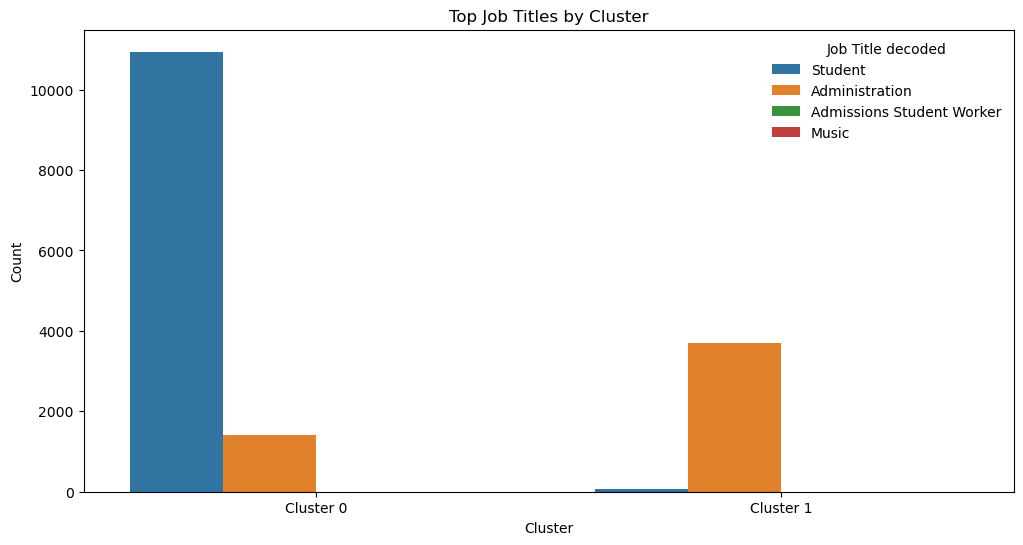

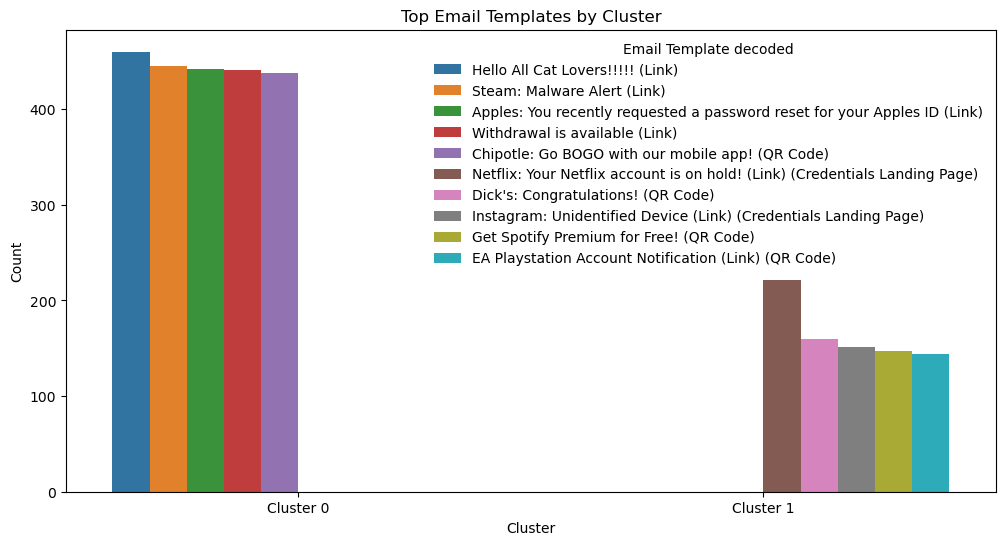

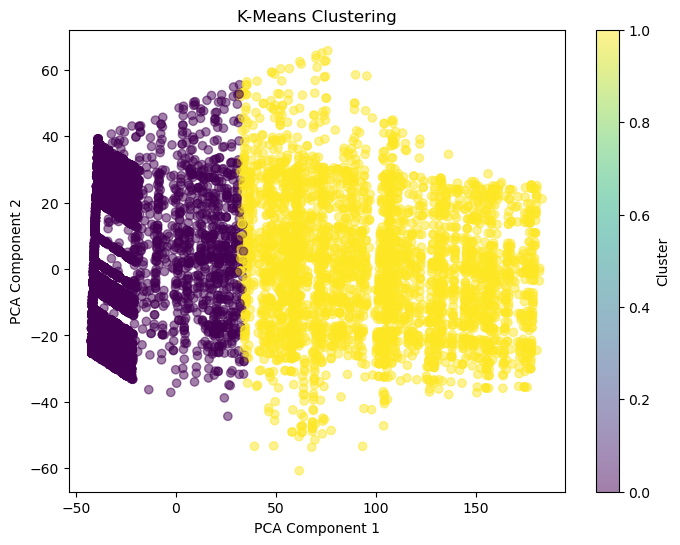


=== Clustering Results ===
K-Means Cluster Distribution: Counter({0: 12354, 1: 3768})


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Ensure label encoders exist
if "label_encoders" not in globals():
    raise ValueError("Label encoders not found. Ensure categorical encoding has been performed before running this.")

# Decode Job Title and Email Template using stored label encoders
df["Job Title decoded"] = df["Job Title"].map(lambda x: label_encoders["Job Title"].inverse_transform([x])[0])
df["Email Template decoded"] = df["Email Template"].map(lambda x: label_encoders["Email Template"].inverse_transform([x])[0])

# Analyze job titles based on 'Cluster' status
job_title_cluster = df.groupby(["Cluster", "Job Title decoded"]).size().reset_index(name="Count")
top_job_titles = job_title_cluster.groupby("Cluster").apply(lambda x: x.nlargest(5, "Count")).reset_index(drop=True)

# Analyze email templates based on 'Cluster' status
email_template_cluster = df.groupby(["Cluster", "Email Template decoded"]).size().reset_index(name="Count")
top_email_templates = email_template_cluster.groupby("Cluster").apply(lambda x: x.nlargest(5, "Count")).reset_index(drop=True)

# Display the top job titles per 'Cluster' status
print("\nTop Job Titles per Cluster:")
print(top_job_titles)

# Display the top email templates per 'Cluster' status
print("\nTop Email Templates per Cluster:")
print(top_email_templates)

# =============================
# VISUALIZATION
# =============================

# Visualize the job titles per 'Cluster' status
plt.figure(figsize=(12, 6))
sns.barplot(data=top_job_titles, x="Cluster", y="Count", hue="Job Title decoded")
plt.title("Top Job Titles by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks(ticks=top_job_titles["Cluster"].unique(), labels=[f"Cluster {i}" for i in top_job_titles["Cluster"].unique()])
plt.legend(title="Job Title decoded", bbox_to_anchor=(1, 1), frameon=False)
plt.show()

# Visualize the email templates per 'Cluster' status
plt.figure(figsize=(12, 6))
sns.barplot(data=top_email_templates, x="Cluster", y="Count", hue="Email Template decoded")
plt.title("Top Email Templates by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks(ticks=top_email_templates["Cluster"].unique(), labels=[f"Cluster {i}" for i in top_email_templates["Cluster"].unique()])
plt.legend(title="Email Template decoded", bbox_to_anchor=(1, 1), frameon=False)
plt.show()

# =============================
# PCA for Clustering Visualization
# =============================

# Reduce dimensions using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot K-Means Clustering
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], cmap="viridis", alpha=0.5)
plt.title("K-Means Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

# =============================
# RESULTS SUMMARY
# =============================

print("\n=== Clustering Results ===")
print("K-Means Cluster Distribution:", Counter(df["Cluster"]))
